# Short-Video Addiction- Phase **1**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [2]:
#Load Dataset
df = pd.read_csv("Short-Videos Addiction.csv")

#  EDA

In [3]:
#Print first 10 rows
df.head(10)

,Timestamp,Gender,Age Group,"How many hours do you spend daily watching short-form videos (TikTok, Reels, Shorts)?",How many times do you open short-video apps per hour?,Have you tried to reduce your short-video usage?,Do you feel like you lose track of time once you start scrolling?,Do you find it difficult to stop watching even when you have urgent tasks?,Do you feel annoyed or bored quickly when watching long-form videos (more than 10 minutes)?,Do you use short videos as a primary way to escape from stress or boredom?,Have you noticed that your sleep quality or bedtime is affected by watching?,Target
0,28/03/2026 15:35,0,1,1,1,1,1,2,1,2,2,1
1,28/03/2026 15:40,0,1,3,3,0,3,2,1,2,1,2
2,28/03/2026 15:41,0,1,3,3,2,3,3,1,3,2,2
3,28/03/2026 15:42,0,1,3,3,2,2,2,0,2,2,2
4,28/03/2026 15:44,1,3,0,0,1,2,0,1,1,2,0
5,28/03/2026 15:44,0,1,2,3,0,2,1,0,1,1,1
6,28/03/2026 15:45,0,1,2,3,2,3,1,1,2,2,2
7,28/03/2026 15:46,0,2,1,3,0,2,1,1,3,2,2
8,28/03/2026 15:50,0,1,2,1,1,1,0,1,0,1,0
9,28/03/2026 15:50,0,1,1,1,1,3,3,1,2,0,2


In [4]:
df.columns = [
    "timestamp",
    "gender",
    "age_group",
    "daily_hours",
    "open_freq",
    "reduce_try",
    "time_loss",
    "hard_stop",
    "long_vid_bored",
    "escape_use",
    "sleep_impact",
    "target"
]

Key

Gender
0 = Female
1 = Male

Age Group
0 = Under 18
1 = 18 - 24 years
2 = 25 - 34 years
3 = 35+ years

How many hours do you spend daily watching short-form videos (TikTok, Reels, Shorts)?
0 = Less than 1 hour
1 = 1 - 3 hours
2 = 3 - 5 hours
3 = More than 5 hours

How many times do you open short-video apps per hour?
0 = 1 - 2 times
1 = 3 - 5 times
2 = More than 5 times
3 = Constantly (Automatic habit)

Have you tried to reduce your short-video usage?
0 = I haven't tried
1 = I tried and succeeded
2 = I tried but failed

Do you feel like you lose track of time once you start scrolling?
0 = Rarely
1 = Sometimes
2 = Often
3 = Always

Do you find it difficult to stop watching even when you have urgent tasks?
0 = Rarely
1 = Sometimes
2 = Often
3 = Always

Do you feel annoyed or bored quickly when watching long-form videos (more than 10 minutes)?
0 = No
1 = Yes

Do you use short videos as a primary way to escape from stress or boredom?
0 = Rarely
1 = Sometimes
2 = Often
3 = Always

Have you noticed that your sleep quality or bedtime is affected by watching?
0 = Not at all
1 = Sometimes
2 = Yes, significantly

In [5]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (215, 12)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       215 non-null    object
 1   gender          215 non-null    int64 
 2   age_group       215 non-null    int64 
 3   daily_hours     215 non-null    int64 
 4   open_freq       215 non-null    int64 
 5   reduce_try      215 non-null    int64 
 6   time_loss       215 non-null    int64 
 7   hard_stop       215 non-null    int64 
 8   long_vid_bored  215 non-null    int64 
 9   escape_use      215 non-null    int64 
 10  sleep_impact    215 non-null    int64 
 11  target          215 non-null    int64 
dtypes: int64(11), object(1)
memory usage: 20.3+ KB


In [7]:
df.describe()

,gender,age_group,daily_hours,open_freq,reduce_try,time_loss,hard_stop,long_vid_bored,escape_use,sleep_impact,target
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,0.274419,1.511628,1.609302,1.562791,0.962791,1.679070,1.218605,0.669767,1.558140,1.162791,1.139535
std,0.447262,0.879998,0.974395,1.153828,0.825138,0.924374,0.982857,0.471394,0.983564,0.752883,0.814053
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
50%,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000
75%,1.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000
max,1.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,1.000000,3.000000,2.000000,2.000000


In [8]:
#Check Missing Values
df.isnull().sum()

timestamp         0
gender            0
age_group         0
daily_hours       0
open_freq         0
reduce_try        0
time_loss         0
hard_stop         0
long_vid_bored    0
escape_use        0
sleep_impact      0
target            0
dtype: int64

In [9]:
#Check Duplicates
df.duplicated().sum()

0

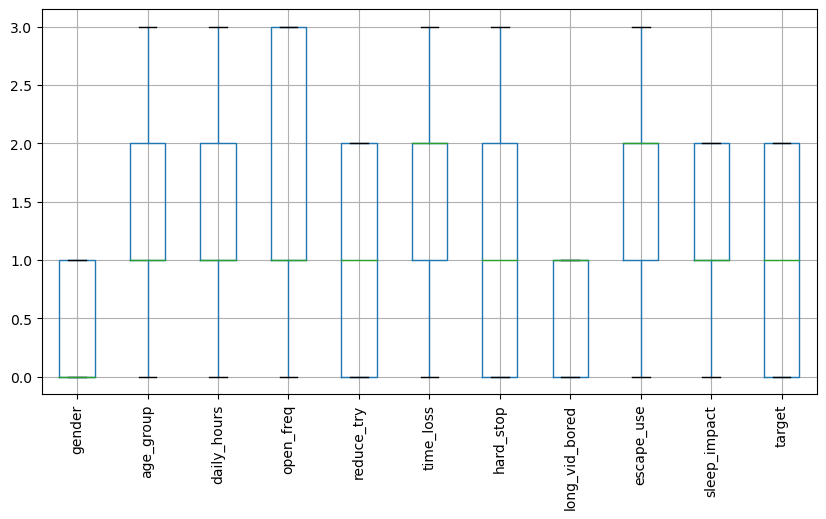

In [10]:
#Outliers Check (Boxplot)
df.boxplot(figsize=(10,5))
plt.xticks(rotation=90)
plt.show()

No significant outliers were found since the data was collected using predefined categorical options.

In [11]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['gender', 'age_group', 'daily_hours', 'open_freq', 'reduce_try',
       'time_loss', 'hard_stop', 'long_vid_bored', 'escape_use',
       'sleep_impact', 'target'],
      dtype='object')

# Data Cleaning

In [12]:
#Make a copy of data
df_clean = df.copy()

In [13]:
#Remove Extra Spaces
df_clean.columns = df_clean.columns.str.strip()

In [14]:
#Removing Unnecessary Column
df_clean.drop('timestamp', inplace=True, axis=1)

In [15]:
df_clean.shape

(215, 11)

In [16]:
print(df_clean.columns)

Index(['gender', 'age_group', 'daily_hours', 'open_freq', 'reduce_try',
       'time_loss', 'hard_stop', 'long_vid_bored', 'escape_use',
       'sleep_impact', 'target'],
      dtype='object')


#  Target

---



In [17]:
# Print out the number of data for target feature (output)
df_clean['target'].value_counts()

target
2    88
1    69
0    58
Name: count, dtype: int64

Key

2 = Addicted
1 = At Risk
0 = Not Addicted

In [18]:
num_cols = df_clean.select_dtypes(include=np.number).columns
num_cols

Index(['gender', 'age_group', 'daily_hours', 'open_freq', 'reduce_try',
       'time_loss', 'hard_stop', 'long_vid_bored', 'escape_use',
       'sleep_impact', 'target'],
      dtype='object')

In [19]:
#Print first 10 rows after preprocessing
df.head(10)

,timestamp,gender,age_group,daily_hours,open_freq,reduce_try,time_loss,hard_stop,long_vid_bored,escape_use,sleep_impact,target
0,28/03/2026 15:35,0,1,1,1,1,1,2,1,2,2,1
1,28/03/2026 15:40,0,1,3,3,0,3,2,1,2,1,2
2,28/03/2026 15:41,0,1,3,3,2,3,3,1,3,2,2
3,28/03/2026 15:42,0,1,3,3,2,2,2,0,2,2,2
4,28/03/2026 15:44,1,3,0,0,1,2,0,1,1,2,0
5,28/03/2026 15:44,0,1,2,3,0,2,1,0,1,1,1
6,28/03/2026 15:45,0,1,2,3,2,3,1,1,2,2,2
7,28/03/2026 15:46,0,2,1,3,0,2,1,1,3,2,2
8,28/03/2026 15:50,0,1,2,1,1,1,0,1,0,1,0
9,28/03/2026 15:50,0,1,1,1,1,3,3,1,2,0,2


# Data Visualizations




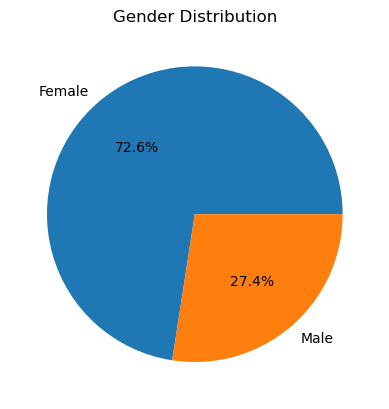

In [20]:
df_clean['gender'].map({0:'Female',1:'Male'}).value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel('')
plt.show()

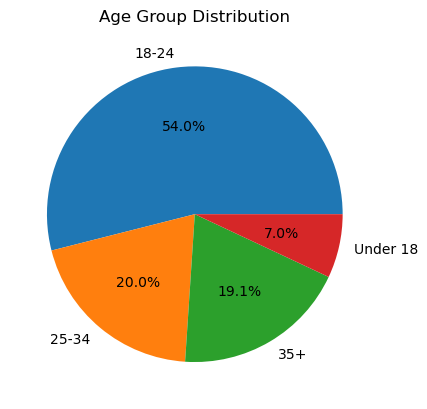

In [21]:
age_labels = {
    0: 'Under 18',
    1: '18-24',
    2: '25-34',
    3: '35+'
}

df_clean['age_group'].map(age_labels).value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Age Group Distribution")
plt.ylabel('')
plt.show()

In [22]:
df_clean.hist(figsize=(35,20))

array([[<Axes: title={'center': 'gender'}>,
        <Axes: title={'center': 'age_group'}>,
        <Axes: title={'center': 'daily_hours'}>],
       [<Axes: title={'center': 'open_freq'}>,
        <Axes: title={'center': 'reduce_try'}>,
        <Axes: title={'center': 'time_loss'}>],
       [<Axes: title={'center': 'hard_stop'}>,
        <Axes: title={'center': 'long_vid_bored'}>,
        <Axes: title={'center': 'escape_use'}>],
       [<Axes: title={'center': 'sleep_impact'}>,
        <Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

In [23]:
sns.countplot(x='target', data=df_clean)

<Axes: xlabel='target', ylabel='count'>

2 = Addicted

1 = At Risk

0 = Not Addicted

The distribution of the target variable shows that most respondents are classified as addicted (class 2), followed by at-risk individuals (class 1), while the smallest group is not addicted (class 0). This indicates a relatively high level of addiction among participants.

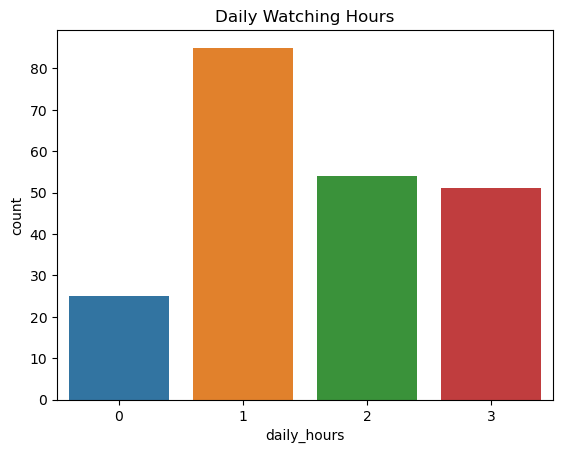

In [25]:
sns.countplot(x='daily_hours', data=df_clean)
plt.title("Daily Watching Hours")
plt.show()

How many hours do you spend daily watching short-form videos (TikTok, Reels, Shorts)?

0 = Less than 1 hour

1 = 1 - 3 hours

2 = 3 - 5 hours

3 = More than 5 hours

Most participants spend between 1 to 3 hours daily watching short-form videos. A significant number also spend 3 to 5 hours, and a noticeable portion exceed 5 hours per day, while only a small group watches less than one hour.

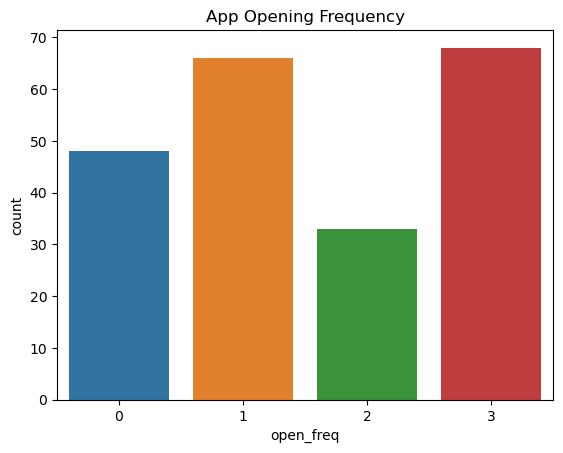

In [26]:
sns.countplot(x='open_freq', data=df_clean)
plt.title("App Opening Frequency")
plt.show()

How many times do you open short-video apps per hour?

0 = 1 - 2 times

1 = 3 - 5 times

2 = More than 5 times

3 = Constantly (Automatic habit)

The high number of users who open apps constantly suggests the presence of automatic behavior, which is a strong indicator of addictive patterns. Frequent app checking may reflect reduced self-control and increased dependency on short-form video platforms.

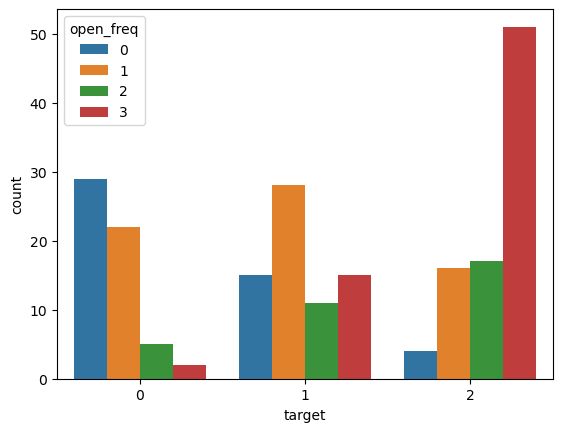

In [28]:
sns.countplot(x='target', hue='open_freq', data=df_clean)
plt.show()

How many times do you open short-video apps per hour?

0 = 1 - 2 times

1 = 3 - 5 times

2 = More than 5 times

3 = Constantly (Automatic habit)


Target

2 = Addicted

1 = At Risk

0 = Not Addicted

The results show a clear relationship between app opening frequency and addiction levels. Users who open the app constantly are mostly classified as addicted, while those who open it only 1–2 times per hour are more likely to be not addicted. This indicates that frequent and automatic app usage is strongly associated with higher addiction levels.

App opening frequency is one of the strongest predictors of addiction.

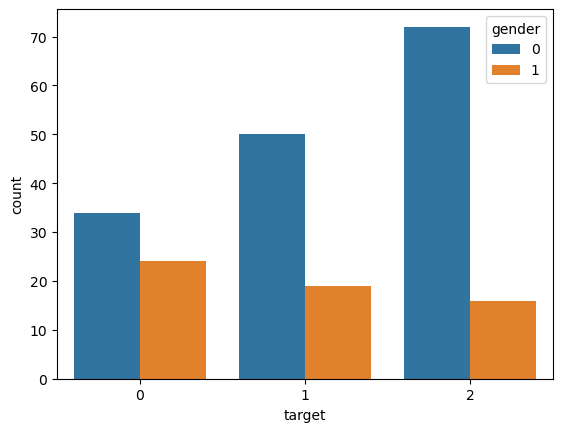

In [29]:
sns.countplot(x='target', hue='gender', data=df_clean)
plt.show()

In [30]:
pd.crosstab(df_clean['gender'], df_clean['target'], normalize='index')

target,0,1,2
gender,,,
0,0.217949,0.320513,0.461538
1,0.406780,0.322034,0.271186


Gender

0 = Female

1 = Male

Target

2 = Addicted

1 = At Risk

0 = Not Addicted

Females show a higher tendency toward addiction compared to males, while males are more likely to be non-addicted.
This result may also be influenced by the higher number of female respondents in the dataset.

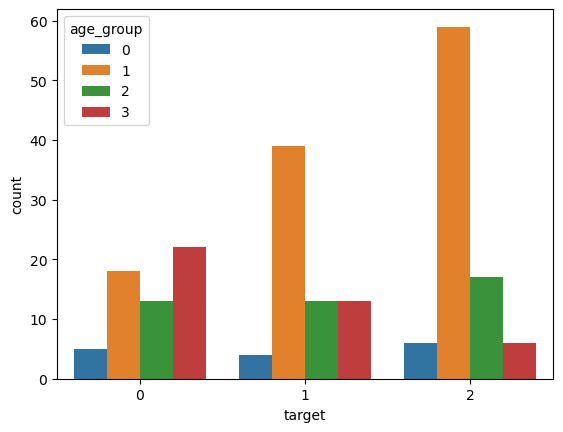

In [32]:
sns.countplot(x='target', hue='age_group', data=df_clean)
plt.show()

Age Group

0 = Under 18

1 = 18 - 24 years

2 = 25 - 34 years

3 = 35+ years

The age group 18–24 shows the highest number of addicted users, while users aged 35+ are more likely to be non-addicted.

#Prepare data

In [33]:
# Select all columns except 'target' as features
X = df_clean.iloc[:, :-1].values

# Select 'target' as the label
y = df_clean.iloc[:,10].values

In [35]:
mm_scaler = MinMaxScaler()
X_mm = mm_scaler.fit_transform(X)

In [36]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_mm, y, test_size=0.3, random_state=42, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, random_state=0
)

In [37]:
# Proceed with the split and training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_valid.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")

Training set:   172 samples
Validation set: 38 samples
Test set:       43 samples


# LogisticRegression

In [39]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
# Making predictions on the test and train sets
y_pred = model_lr.predict(X_test)
y_pred_train=model_lr.predict(X_train)

In [41]:
# Displaying Evaluation Metrics
print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))

Training Accuracy: 1.0
Testing Accuracy: 0.9534883720930233


#### Overfitting and Underfitting Analysis


The model achieved 100% training accuracy, meaning it correctly classified every single sample in the training dataset. This indicates the model learned the training data perfectly.
The model achieved 95.35% testing accuracy on unseen data, meaning it correctly predicted 41 out of 43 test samples. This is excellent and shows the model generalizes well to new data.

 why it is not Overfitting?

 For Logistic Regression, a training accuracy of 100% and testing accuracy of 95.35% is NOT considered significant overfitting. The gap is only 4.65%, which is acceptable.



In [42]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.85      1.00      0.92        11
           2       1.00      0.90      0.95        20

    accuracy                           0.95        43
   macro avg       0.95      0.97      0.95        43
weighted avg       0.96      0.95      0.95        43



Class 0 (Low Addiction): Precision, recall, and F1-score are all 1.00, meaning the model perfectly identified all Low Addiction users with no mistakes.

Class 1 (Moderate Addiction): Precision is 0.85, recall is 1.00, and F1-score is 0.92. This means all Moderate Addiction users were found (recall 100%), but some predictions for this class were incorrect (precision 85%).

Class 2 (High Addiction): Precision is 1.00, recall is 0.90, and F1-score is 0.95. This means every prediction made for High Addiction was correct (precision 100%), but the model missed 2 High Addiction users (recall 90%).



In [43]:
# 1. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

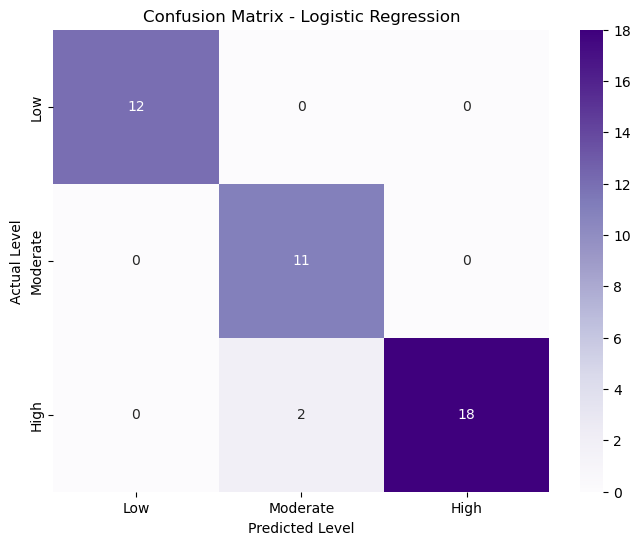

In [44]:
# 2. Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Low', 'Moderate', 'High'],
            yticklabels=['Low', 'Moderate', 'High'])

# 3. Add labels and title for the report
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Level')
plt.ylabel('Actual Level')
plt.show()

12 Low Addiction users → all correctly predicted as Low

11 Moderate Addiction users → all correctly predicted as Moderate

20 High Addiction users → 18 correctly predicted as High , 2 incorrectly predicted as Moderate

Only 2 mistakes were made out of 43 total samples. Both mistakes were High Addiction users predicted as Moderate Addiction.


# SVM

In [45]:
# Build SVM model
# Train the SVM model on the training set

In [46]:
print(f"Training set: {X_train.shape[0]}")
print(f"Validation set: {X_valid.shape[0]}")
print(f"Test set: {X_test.shape[0]}")

Training set: 172
Validation set: 38
Test set: 43


In [47]:
# Create SVM model
svm_model = svm.SVC()

# FIT the model FIRST
svm_model.fit(X_train, y_train)# Make prediction on the training set

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [48]:
# THEN predict
y_pred_train = svm_model.predict(X_train)
y_pred_test = svm_model.predict(X_test)

In [49]:
# Print results
print("\n" + "- "* 50)
print("SVM - DEFAULT PARAMETERS")
print("-" * 50)
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")


- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
SVM - DEFAULT PARAMETERS
--------------------------------------------------
Training Accuracy: 0.9884
Test Accuracy: 0.9535


### Overfitting and Underfitting Analysis

Support Vector Machine (SVM) achieved 98.84% training accuracy and 95.35% testing accuracy.
The training and testing accuracies are very close, which means the model has good generalization and does not suffer from overfitting or underfitting.

In [50]:
# Print Classifcation Report

In [51]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.85      1.00      0.92        11
           2       1.00      0.90      0.95        20

    accuracy                           0.95        43
   macro avg       0.95      0.97      0.95        43
weighted avg       0.96      0.95      0.95        43



Class 0 (Low Addiction):
Precision, recall, and F1-score are all 1.00, meaning the model perfectly identified all Low Addiction users with no mistakes.

Class 1 (Moderate Addiction):
Precision is 0.85, recall is 1.00, and F1-score is 0.92.
This means all Moderate Addiction users were correctly detected (recall 100%), but some predictions for this class were incorrect (precision 85%).

Class 2 (High Addiction):
Precision is 1.00, recall is 0.90, and F1-score is 0.95.
This means all predictions labeled as High Addiction were correct (precision 100%), but the model missed 2 High Addiction users (recall 90%).

In [52]:
cm_s = confusion_matrix(y_test, y_pred_test)

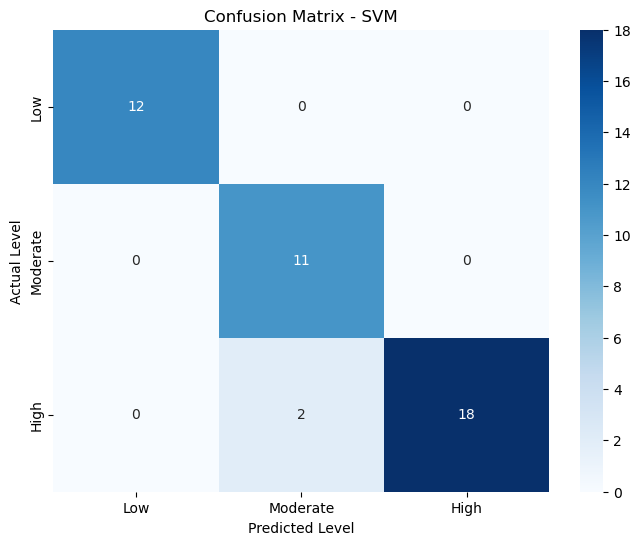

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Moderate', 'High'],
            yticklabels=['Low', 'Moderate', 'High'])

# 3. Add labels and title for the report
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted Level')
plt.ylabel('Actual Level')
plt.show()

12 Low Addiction users → all correctly predicted as Low

11 Moderate Addiction users → all correctly predicted as Moderate

20 High Addiction users → 18 correctly predicted as High, 2 incorrectly predicted as Moderate

Only 2 mistakes were made out of 43 total samples. Both mistakes were High Addiction users predicted as Moderate Addiction.

# RandomForest

In [54]:
rf = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")

Training Accuracy: 0.9884
Testing Accuracy:  0.9535


In [57]:
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

In [58]:
CRrf = classification_report(y_test, y_pred_test)
print("Random Forest Classification Report:")
print(CRrf)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.73      1.00      0.85        11
           2       1.00      0.80      0.89        20

    accuracy                           0.91        43
   macro avg       0.91      0.93      0.91        43
weighted avg       0.93      0.91      0.91        43



Class 0 (Low Addiction):
Precision, recall, and F1-score are all 1.00, meaning the model perfectly identified all Low Addiction users with no mistakes.

Class 1 (Moderate Addiction):
Precision is 0.73, recall is 1.00, and F1-score is 0.85.
This means all Moderate Addiction users were correctly detected (recall 100%), but several predictions for this class were incorrect (precision 73%).

Class 2 (High Addiction):
Precision is 1.00, recall is 0.80, and F1-score is 0.89.
This means all predictions labeled as High Addiction were correct (precision 100%), but the model missed 4 High Addiction users (recall 80%)

### Overfitting and Underfitting Analysis

Random Forest achieved 100% training accuracy but only 90.70% testing accuracy.
The large gap between training and testing accuracy indicates that the model suffers from overfitting, as it performs very well on training data but worse on unseen data

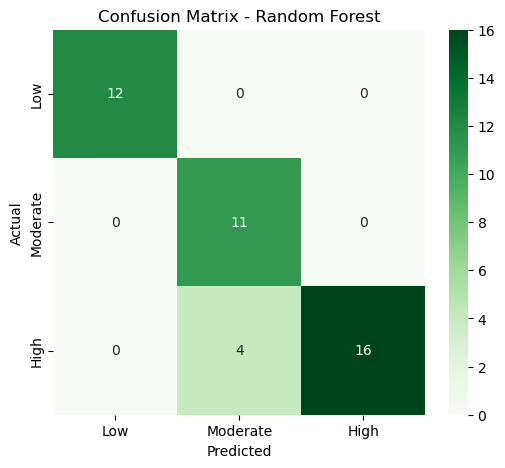

In [59]:
cm_rf = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low', 'Moderate', 'High'],
            yticklabels=['Low', 'Moderate', 'High'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

12 Low Addiction users → all correctly predicted as Low

11 Moderate Addiction users → all correctly predicted as Moderate

20 High Addiction users → 16 correctly predicted as High, 4 incorrectly predicted as Moderate

Only 4 mistakes were made out of 43 total samples. All mistakes were High Addiction users predicted as Moderate Addiction.

## Applying Feature Scaling (MinMaxScaler) on the Worst Model (Random Forest)

In [60]:

mm_scaler =MinMaxScaler()
X_mm = mm_scaler.fit_transform(X)


X_train2, X_test2, y_train2, y_test2 = train_test_split(X_mm, y, test_size=0.2, random_state=42)


rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_train2, y_train2)


y_train_pred2 = rf2.predict(X_train2)
y_pred2 = rf2.predict(X_test2)


print("Training Accuracy after Scaling:", accuracy_score(y_train2, y_train_pred2))
print("Testing Accuracy after Scaling:", accuracy_score(y_test2, y_pred2))

Training Accuracy after Scaling: 1.0
Testing Accuracy after Scaling: 0.9069767441860465


After applying MinMaxScaler and rebuilding the Random Forest model, the performance did not improve significantly.
This is because Random Forest is not sensitive to feature scaling.

# Model Improvement using Grid Search

In [61]:
best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:

        # Initialize and fit SVC with current parameters
        model = svm.SVC(gamma=gamma, C=C)
        model.fit(X_train, y_train)

        # Perform cross-validation
        scores = cross_val_score(model, X_trainval, y_trainval, cv=5)

        # Compute mean cross-validation accuracy
        score = np.mean(scores)

        # If we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_params = {'C': C, 'gamma': gamma}

print(f"Best score: {best_score:.4f}")
print(f"Best parameters: {best_params}")

Best score: 0.9333
Best parameters: {'C': 100, 'gamma': 0.01}


In [62]:
# Get best parameters
best_gamma = best_params['gamma']
best_C = best_params['C']

# Train on X_train (same as other models), NOT X_trainval
final_svm = svm.SVC(gamma=best_gamma, C=best_C)
final_svm.fit(X_train, y_train)

# Make predictions on test set
y_pred_test = final_svm.predict(X_test)

In [63]:
print("\n" + "=" * 50)
print("FINAL TUNED SVM MODEL EVALUATION")
print("=" * 50)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

print("\nClassification Report (Tuned SVM):")
print(classification_report(y_test, y_pred_test))


FINAL TUNED SVM MODEL EVALUATION
Test Accuracy: 0.9535

Classification Report (Tuned SVM):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.85      1.00      0.92        11
           2       1.00      0.90      0.95        20

    accuracy                           0.95        43
   macro avg       0.95      0.97      0.95        43
weighted avg       0.96      0.95      0.95        43



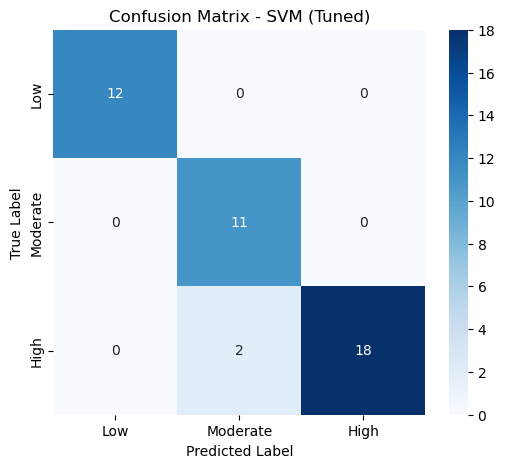

In [64]:
# Confusion Matrix for Tuned SVM
cm_tuned = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Moderate', 'High'],
            yticklabels=['Low', 'Moderate', 'High'])
plt.title('Confusion Matrix - SVM (Tuned)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The SVM model achieved 95.35% testing accuracy with default parameters. Hyperparameter tuning using GridSearchCV did not yield improved performance, suggesting that the default configuration is already well-suited for this dataset. This also indicates that the feature set has strong predictive power for classifying addiction levels."*

In [69]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, model_lr.predict(X_test))
svm_acc = accuracy_score(y_test, svm_model.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))

# Print comparison table
print("\n" + "="*50)
print("MODEL COMPARISON RESULTS")
print("="*50)
print(f"{'Model':<25} {'Test Accuracy':<15}")
print("-"*50)

print(f"{'Logistic Regression':<25} {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"{'SVM':<25} {svm_acc:.4f} ({svm_acc*100:.2f}%)")
print(f"{'Random Forest':<25} {rf_acc:.4f} ({rf_acc*100:.2f}%)")

print("="*50)





MODEL COMPARISON RESULTS
Model                     Test Accuracy  
--------------------------------------------------
Logistic Regression       0.9535 (95.35%)
SVM                       0.9535 (95.35%)
Random Forest             0.9070 (90.70%)
